# LIBRARIES

In [32]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.image as img
%matplotlib inline

# DATA LOAD

In [44]:
!pip install split-folders
import splitfolders
splitfolders.ratio('../input/alzheimer-mri-dataset/Dataset', output="output", seed=1345, ratio=(.8, 0.1,0.1)) 

Copying files: 6400 files [00:06, 1063.57 files/s]


In [33]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
r"G:\Dementia\Starting\SplittedNew\train",
seed=123, label_mode='categorical',
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=64
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
r"G:\Dementia\Starting\SplittedNew\test",
seed=123,label_mode='categorical',
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=64
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
r"G:\Dementia\Starting\SplittedNew\val",
seed=123,label_mode='categorical',
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=64
)

Found 69148 files belonging to 4 classes.
Found 8647 files belonging to 4 classes.
Found 8642 files belonging to 4 classes.


In [34]:
class_names = train_ds.class_names
print(class_names)
train_ds

['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

# EXAMPLE IMAGE

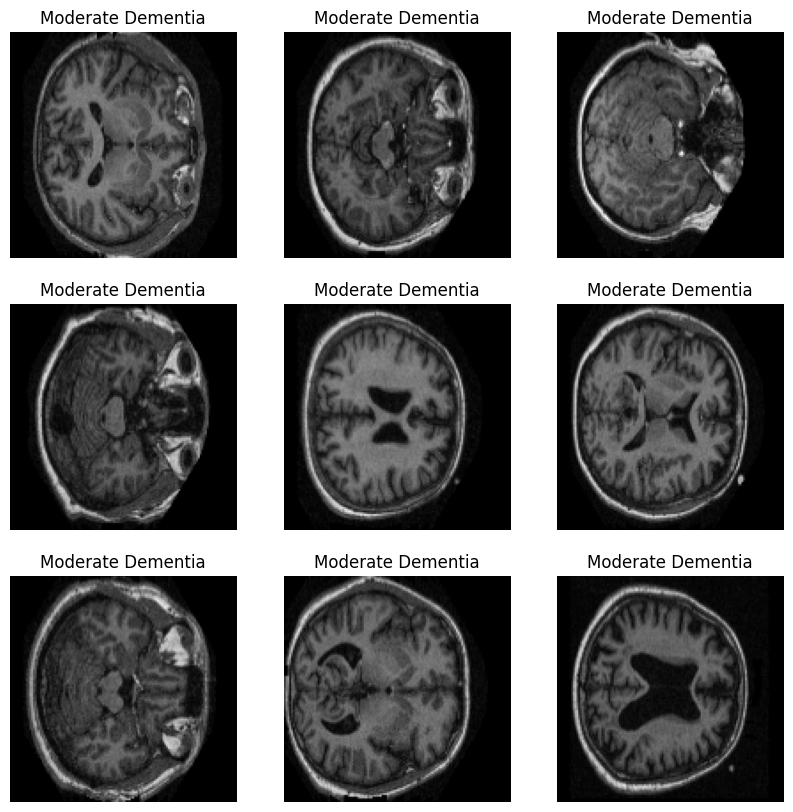

In [35]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(max(labels[i]))])
        plt.axis("off")
        
        


<function matplotlib.pyplot.show(close=None, block=None)>

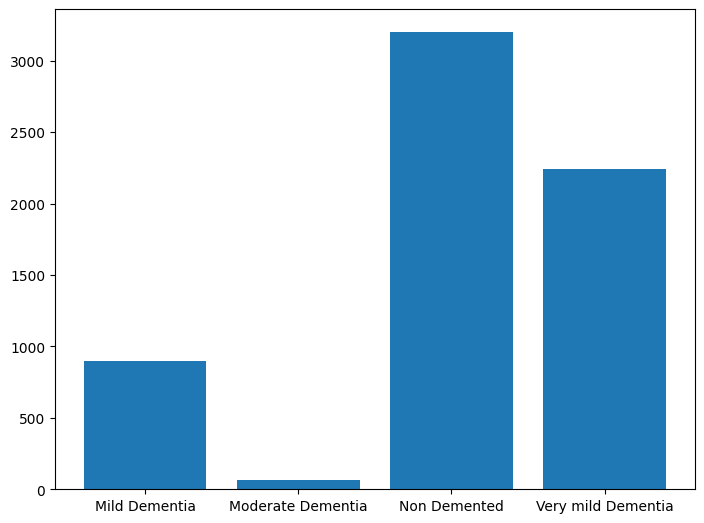

In [36]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
size = [896,64,3200,2240]
ax.bar(class_names,size)
plt.show

# MODEL

In [37]:
model = keras.models.Sequential()
model.add(keras.layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(keras.layers.Conv2D(filters=16,kernel_size=(3,3),padding='same',activation='relu',kernel_initializer="he_normal"))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',kernel_initializer="he_normal"))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Dropout(0.25))

model.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu',kernel_initializer="he_normal"))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128,activation="relu",kernel_initializer="he_normal"))
model.add(keras.layers.Dense(32,"relu"))
model.add(keras.layers.Dense(4,"softmax"))

C:\Users\junai\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.compile(loss="categorical_crossentropy",
              optimizer = "Adam",metrics=['accuracy',
                                tf.keras.metrics.AUC(),
                                tf.keras.metrics.Precision(),
                                tf.keras.metrics.Recall(),])

In [39]:
filepath = './cnn_best_model.keras'

earlystopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    verbose=1,
    restore_best_weights=True   # recommended!
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

callbacks_list = [earlystopping, checkpoint]


In [40]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,125,124 (8.11 MB)

 Trainable params: 2,125,124 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
tf.keras.utils.plot_model(model,show_shapes=True,dpi=150)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    batch_size=64,
    verbose=1,
    callbacks=callbacks_list
)


Epoch 1/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.8151 - auc_1: 0.9540 - loss: 0.5192 - precision_1: 0.8325 - recall_1: 0.7922
Epoch 1: val_accuracy improved from -inf to 0.96424, saving model to ./cnn_best_model.keras
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 455s 418ms/step - accuracy: 0.8152 - auc_1: 0.9540 - loss: 0.5191 - precision_1: 0.8326 - recall_1: 0.7922 - val_accuracy: 0.9642 - val_auc_1: 0.9984 - val_loss: 0.1030 - val_precision_1: 0.9692 - val_recall_1: 0.9603
Epoch 2/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9557 - auc_1: 0.9970 - loss: 0.1175 - precision_1: 0.9580 - recall_1: 0.9536
Epoch 2: val_accuracy improved from 0.96424 to 0.99676, saving model to ./cnn_best_model.keras
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 434s 401ms/step - accuracy: 0.9557 - auc_1: 0.9970 - loss: 0.1174 - precision_1: 0.9580 - recall_1: 0.9536 - val_accuracy: 0.9968 - val_auc_1: 1.0000 - val_loss: 0.0205 - val_precision_1: 0.9971 - val_recall_1: 0.9966
Epoch 3/10
 137/1081 

# Plot the result


In [15]:
result = model.evaluate(test_ds)
train_loss = result[0]
train_accuracy = result[1]
train_AUC = result[2]
train_pre = result[3]
train_rec = result[4]
print(f'Test Loss = {train_loss}')
print(f'Test Accuracy = {train_accuracy}')
print(f'Test AUC = {train_AUC}')
print(f'Test Precision = {train_pre}')
print(f'Test Recall = {train_rec}')

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.9864 - auc: 0.9997 - loss: 0.0398 - precision: 0.9864 - recall: 0.9864
Test Loss = 0.04267122596502304
Test Accuracy = 0.9844236969947815
Test AUC = 0.9996898174285889
Test Precision = 0.9844236969947815
Test Recall = 0.9844236969947815


In [17]:
get_ac   = hist.history['accuracy']
get_los  = hist.history['loss']
get_pre  = hist.history['precision']
get_rec  = hist.history['recall']
get_auc  = hist.history['auc']

val_acc  = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_pre  = hist.history['val_precision']
val_rec  = hist.history['val_recall']
val_auc  = hist.history['val_auc']


<Figure size 640x480 with 0 Axes>

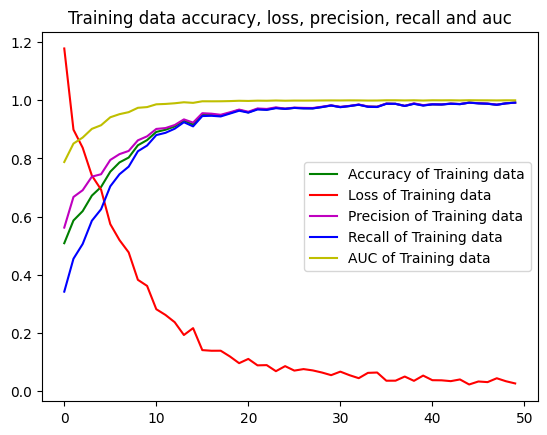

<Figure size 640x480 with 0 Axes>

In [18]:
epochs = range(len(get_ac))
plt.plot(epochs, get_ac, 'g', label='Accuracy of Training data')
plt.plot(epochs, get_los, 'r', label='Loss of Training data')
plt.plot(epochs, get_pre, 'm', label='Precision of Training data')
plt.plot(epochs, get_rec, 'b', label='Recall of Training data')
plt.plot(epochs, get_auc, 'y', label='AUC of Training data')

plt.title('Training data accuracy, loss, precision, recall and auc')
plt.legend(loc=0)
plt.figure()

# plt.plot(epochs, get_ac, 'g', label='Accuracy of Training Data')
# plt.plot(epochs, val_acc, 'r', label='Accuracy of Validation Data')
# plt.title('Training and Validation Accuracy')
# plt.legend(loc=0)
# plt.figure()

# plt.plot(epochs, get_los, 'g', label='Loss of Training Data')
# plt.plot(epochs, val_loss, 'r', label='Loss of Validation Data')
# plt.title('Training and Validation Loss')
# plt.legend(loc=0)
# plt.figure()
# plt.show()

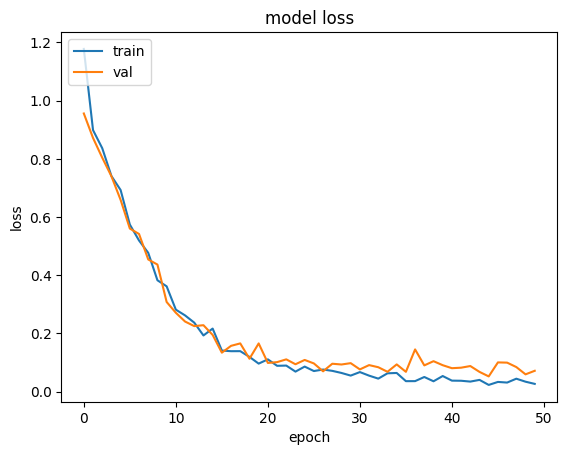

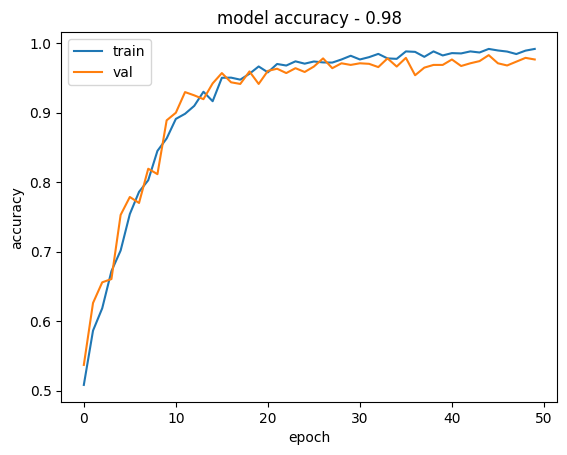

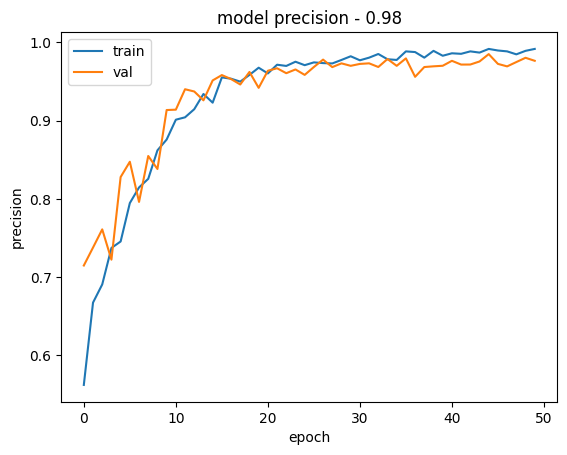

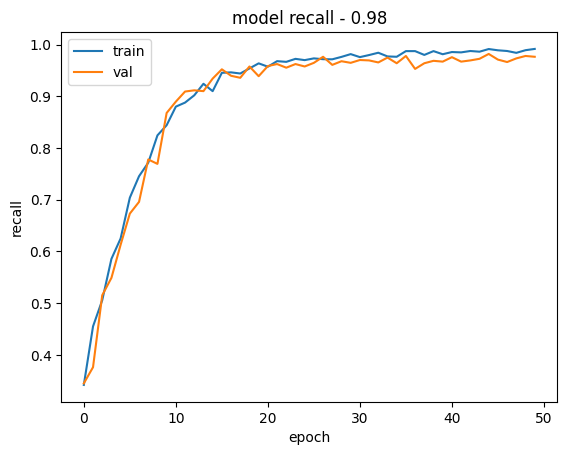

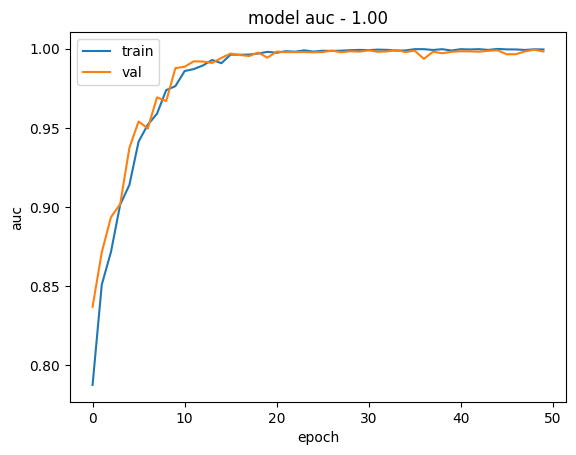

In [20]:
# Loss
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Accuracy
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy - ' + str(format(result[1], "0.2f")))
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Precision
plt.plot(hist.history['precision'])
plt.plot(hist.history['val_precision'])
plt.title('model precision - ' + str(format(result[3], "0.2f")))
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Recall
plt.plot(hist.history['recall'])
plt.plot(hist.history['val_recall'])
plt.title('model recall - ' + str(format(result[4], "0.2f")))
plt.ylabel('recall')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# AUC
plt.plot(hist.history['auc'])
plt.plot(hist.history['val_auc'])
plt.title('model auc - ' + str(format(result[2], "0.2f")))
plt.ylabel('auc')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


### Confusion Matrix

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


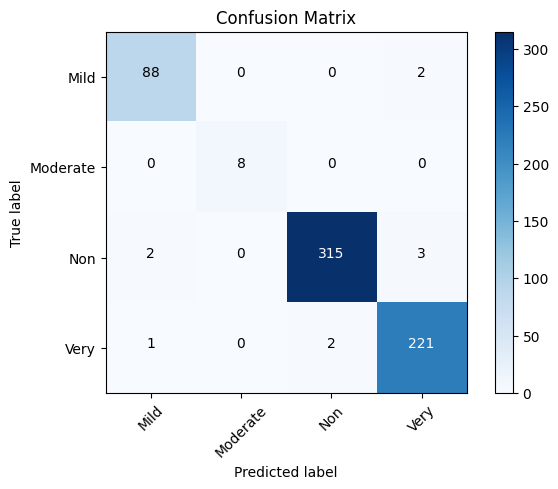

In [21]:
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from itertools import product
y_pred = []  # store predicted labels
y_true = []  # store true labels

# iterate over the dataset
for image_batch, label_batch in test_ds:   # use dataset.unbatch() with repeat
   # append true labels
   y_true.append(label_batch)
   # compute predictions
   preds = model.predict(image_batch)
   # append predicted labels
   y_pred.append(np.argmax(preds, axis = 1))

# convert the true and predicted labels into tensors
correct_labels = tf.concat([item for item in y_true], axis = 0)
predicted_labels = tf.concat([item for item in y_pred], axis = 0)
correct_labels = np.argmax(correct_labels,axis=1)
confusion_mtx = confusion_matrix(correct_labels, predicted_labels)

# Define the class labels
class_names = ['Mild', 'Moderate', 'Non', 'Very']

# Plot the confusion matrix
plt.imshow(confusion_mtx, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
fmt = 'd'
thresh = confusion_mtx.max() / 2.
for i, j in product(range(confusion_mtx.shape[0]), range(confusion_mtx.shape[1])):
    plt.text(j, i, format(confusion_mtx[i, j], fmt),
             horizontalalignment="center",
             color="white" if confusion_mtx[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_names = train_ds.class_names
y = np.concatenate([y for x, y in train_ds], axis=0)
y = np.argmax(y, axis=1)

class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: 1.7858851674641147, 1: 25.448863636363637, 2: 0.49988839285714287, 3: 0.7141262755102041}


In [23]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks_list,
    class_weight=class_weights
)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9846 - auc: 0.9994 - loss: 0.0307 - precision: 0.9855 - recall: 0.9845
Epoch 1: val_accuracy did not improve from 0.98280
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 251ms/step - accuracy: 0.9846 - auc: 0.9994 - loss: 0.0308 - precision: 0.9855 - recall: 0.9845 - val_accuracy: 0.9805 - val_auc: 0.9989 - val_loss: 0.0605 - val_precision: 0.9819 - val_recall: 0.9758
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9803 - auc: 0.9989 - loss: 0.0431 - precision: 0.9807 - recall: 0.9803
Epoch 2: val_accuracy did not improve from 0.98280
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 248ms/step - accuracy: 0.9802 - auc: 0.9989 - loss: 0.0431 - precision: 0.9807 - recall: 0.9802 - val_accuracy: 0.9820 - val_auc: 0.9990 - val_loss: 0.0575 - val_precision: 0.9827 - val_recall: 0.9797
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9842 - auc: 0.9996 - loss: 0.0377 - precision: 0.9848 - recall: 0.9842
Epoch 3: val_accuracy d

In [24]:
result = model.evaluate(test_ds)
train_loss = result[0]
train_accuracy = result[1]
train_AUC = result[2]
train_pre = result[3]
train_rec = result[4]
print(f'Test Loss = {train_loss}')
print(f'Test Accuracy = {train_accuracy}')
print(f'Test AUC = {train_AUC}')
print(f'Test Precision = {train_pre}')
print(f'Test Recall = {train_rec}')

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9809 - auc: 0.9995 - loss: 0.0621 - precision: 0.9814 - recall: 0.9809
Test Loss = 0.05870535597205162
Test Accuracy = 0.9828660488128662
Test AUC = 0.9994944930076599
Test Precision = 0.9843993782997131
Test Recall = 0.9828660488128662


In [25]:
get_ac   = hist.history['accuracy']
get_los  = hist.history['loss']
get_pre  = hist.history['precision']
get_rec  = hist.history['recall']
get_auc  = hist.history['auc']

val_acc  = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_pre  = hist.history['val_precision']
val_rec  = hist.history['val_recall']
val_auc  = hist.history['val_auc']


<Figure size 640x480 with 0 Axes>

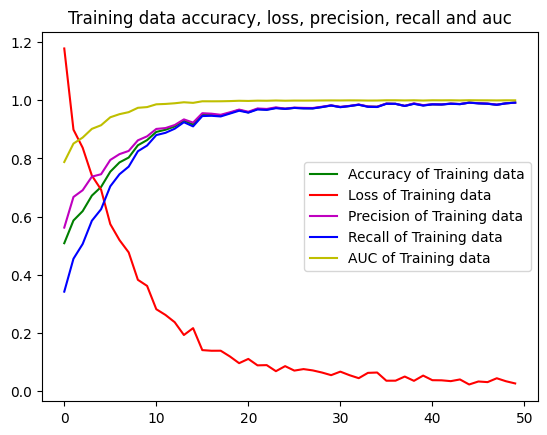

<Figure size 640x480 with 0 Axes>

In [26]:
epochs = range(len(get_ac))
plt.plot(epochs, get_ac, 'g', label='Accuracy of Training data')
plt.plot(epochs, get_los, 'r', label='Loss of Training data')
plt.plot(epochs, get_pre, 'm', label='Precision of Training data')
plt.plot(epochs, get_rec, 'b', label='Recall of Training data')
plt.plot(epochs, get_auc, 'y', label='AUC of Training data')

plt.title('Training data accuracy, loss, precision, recall and auc')
plt.legend(loc=0)
plt.figure()

# plt.plot(epochs, get_ac, 'g', label='Accuracy of Training Data')
# plt.plot(epochs, val_acc, 'r', label='Accuracy of Validation Data')
# plt.title('Training and Validation Accuracy')
# plt.legend(loc=0)
# plt.figure()

# plt.plot(epochs, get_los, 'g', label='Loss of Training Data')
# plt.plot(epochs, val_loss, 'r', label='Loss of Validation Data')
# plt.title('Training and Validation Loss')
# plt.legend(loc=0)
# plt.figure()
# plt.show()

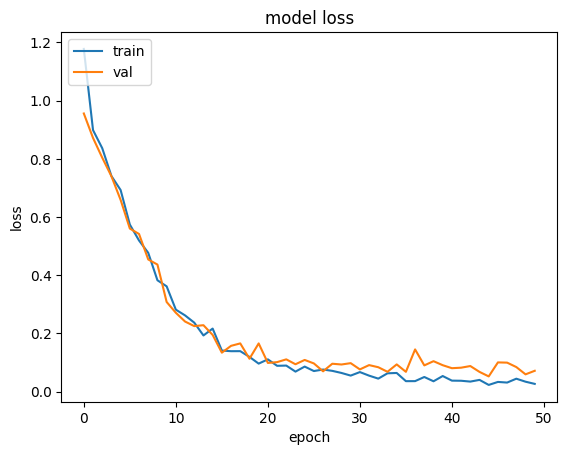

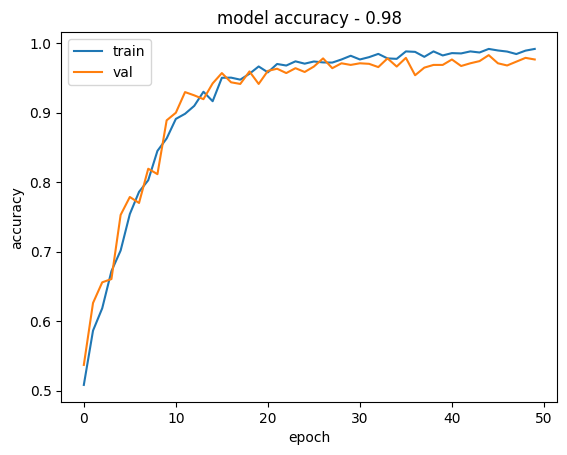

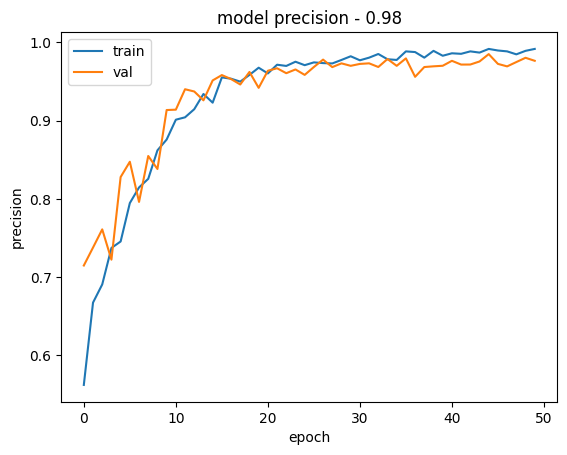

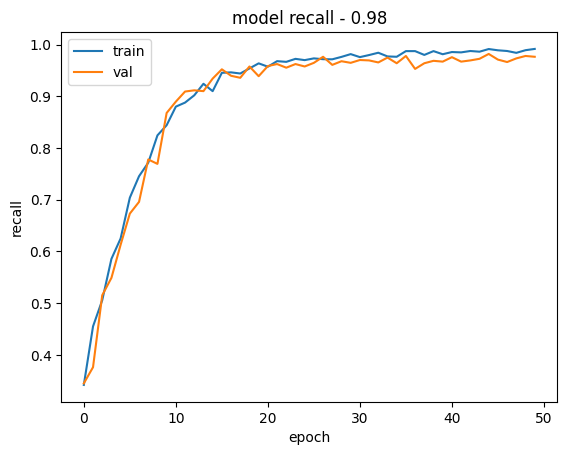

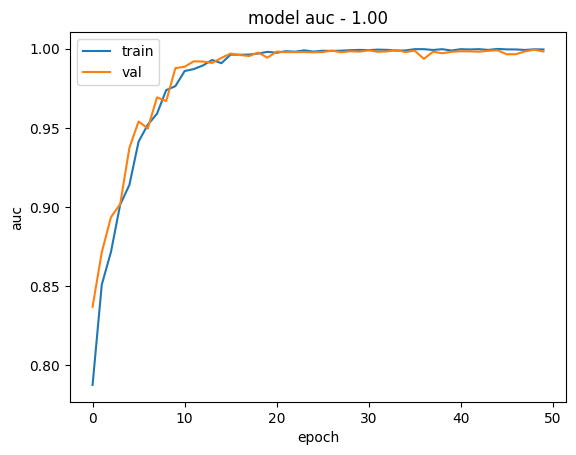

In [27]:
# Loss
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Accuracy
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy - ' + str(format(result[1], "0.2f")))
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Precision
plt.plot(hist.history['precision'])
plt.plot(hist.history['val_precision'])
plt.title('model precision - ' + str(format(result[3], "0.2f")))
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Recall
plt.plot(hist.history['recall'])
plt.plot(hist.history['val_recall'])
plt.title('model recall - ' + str(format(result[4], "0.2f")))
plt.ylabel('recall')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# AUC
plt.plot(hist.history['auc'])
plt.plot(hist.history['val_auc'])
plt.title('model auc - ' + str(format(result[2], "0.2f")))
plt.ylabel('auc')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


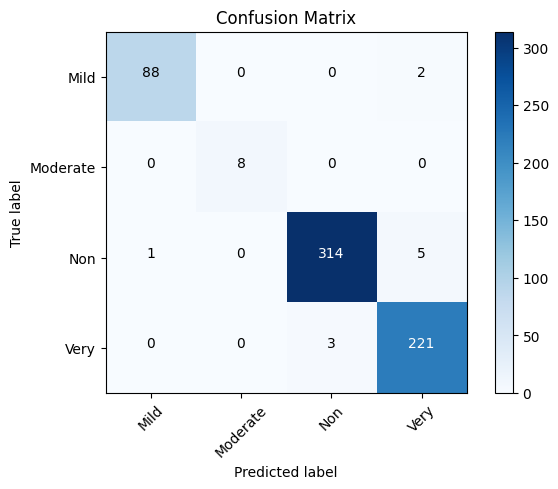

In [28]:
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from itertools import product
y_pred = []  # store predicted labels
y_true = []  # store true labels

# iterate over the dataset
for image_batch, label_batch in test_ds:   # use dataset.unbatch() with repeat
   # append true labels
   y_true.append(label_batch)
   # compute predictions
   preds = model.predict(image_batch)
   # append predicted labels
   y_pred.append(np.argmax(preds, axis = 1))

# convert the true and predicted labels into tensors
correct_labels = tf.concat([item for item in y_true], axis = 0)
predicted_labels = tf.concat([item for item in y_pred], axis = 0)
correct_labels = np.argmax(correct_labels,axis=1)
confusion_mtx = confusion_matrix(correct_labels, predicted_labels)


# Define the class labels
class_names = ['Mild', 'Moderate', 'Non', 'Very']

# Plot the confusion matrix
plt.imshow(confusion_mtx, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
fmt = 'd'
thresh = confusion_mtx.max() / 2.
for i, j in product(range(confusion_mtx.shape[0]), range(confusion_mtx.shape[1])):
    plt.text(j, i, format(confusion_mtx[i, j], fmt),
             horizontalalignment="center",
             color="white" if confusion_mtx[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [29]:
result = model.evaluate(test_ds)
print("Test Accuracy:", result[1])


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9769 - auc: 0.9993 - loss: 0.0724 - precision: 0.9783 - recall: 0.9769
Test Accuracy: 0.9828660488128662


In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=test_ds.class_names))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
                  precision    recall  f1-score   support

    MildDemented       0.99      0.98      0.98        90
ModerateDemented       1.00      1.00      1.00         8
     NonDemented       0.99      0.98      0.99       320
VeryMildDemented       0.97      0.99      0.98       224

        accuracy                           0.98       642
       macro avg       0.99      0.99      0.99       642
    weighted avg       0.98      0.98      0.98       642



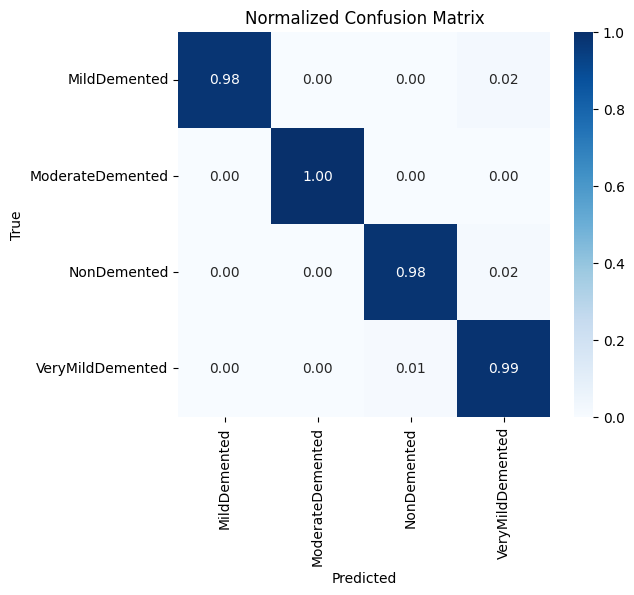

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, cmap='Blues', xticklabels=test_ds.class_names,
            yticklabels=test_ds.class_names, fmt=".2f")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()
